# 06i — Library-backed Soft-DTW + SSG barycenters on representation quality (G=28)

**Kickoff F·S2** of the E→G→F arc. Adds two *library-backed* averagers to the §17 quality harness and
scores them **identically** (extend-by-reuse; no harness change):

- **`soft_dtw_bary`** — Soft-DTW barycenter (Cuturi & Blondel, *ICML 2017*) via `tslearn.barycenters.softdtw_barycenter` (L-BFGS-B), on the `D_G` embedding, decoded to hard symbols. Scored by its **native soft-DTW** distance.
- **`ssg`** — Stochastic-subgradient DTW averaging (Schultz & Jain, *Pattern Recognition 2018*) via `tslearn.barycenters.dtw_barycenter_averaging_subgradient`. Scored by the **native rTWE** distance (like `fgw_*`/`k_medoid`).

**This is a GATED preview.** L=128, reduced `max_iter`, few inits. tslearn's compiled solvers make these
cheap at L=128 (~2 s / ~4.5 s per group vs §17's ~130 s pure-numpy `soft_dtw`/`dba_dtw`), so the L=128 run
is *not* compute-gated here — the genuine gate is **length** (full L≈5162 → O(L²) ≈ 1600× the per-cell cost)
and **cohort**; that scale run is handed off to `pomme` (stub at the bottom, **not run locally**).

Judged on **representation fidelity**, not discrimination AUC (E §15: 0/15 order signals; G §16: local
structure matters only for Patient-vs-Control). Report **per-axis tradeoffs**, no cherry-picked winner.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
os.environ.setdefault('NUMBA_THREADING_LAYER', 'workqueue')  # fork-safe rTWE under nbconvert
import json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
from smartflat.utils.utils_io import get_data_root
from smartflat.features.symbolic_barycenter import vocab
from smartflat.features.symbolic_barycenter import visualization as viz
from smartflat.features.symbolic_barycenter.baselines import (
    default_baseline_methods, barycenter_mode_dba, dist_rtwe,
    fgw_methods, softdtw_ssg_methods)
from smartflat.features.symbolic_barycenter.barycenter_quality import (
    score_barycenter_quality, quality_table)
from smartflat.engine.distances._rtwe import rtwe_pairwise_distance
pd.set_option('display.width', 200, 'display.max_columns', 30)
plt.rcParams['figure.dpi'] = 110

OUT = os.path.join(get_data_root(), 'outputs', 'symbolic_barycenter', 'g28')
EXP = os.path.join(OUT, 'experiments'); os.makedirs(EXP, exist_ok=True)

# Hyperparameters (thesis G=28), shared length gate, and the REDUCED preview budget.
L, NU, LMBDA, RS = 128, 1e-4, 0.1, 42
SDTW_MAX_ITER, SSG_MAX_ITER, N_INITS = 10, 10, 2   # gated preview budget
print('output dir:', EXP)

output dir: /home/perochon/data-gold-final/outputs/symbolic_barycenter/g28/experiments


In [2]:
# Canonical G=28 cohort + ground cost via E's shared loaders (06c Cells 2-3).
# The lock-step / embedding methods need a rectangular length -> upsample to L=128 (the low end
# of 06c's L_SWEEP; gates the O(L^2) barycenter builds). Full L~5162 stays deferred to pomme.
df, X, labels = vocab.load_g28_cohort(upsample_to=L)
D_G = vocab.build_g28_ground_cost(); G = D_G.shape[0]
code_dict = json.load(open(os.path.join(OUT, 'category_codes.json')))
code_to_label = {int(v): k for k, v in code_dict.items()}

# One-time pairwise rTWE (needed by the k_medoid reference); ~seconds at L=128.
D_pw = rtwe_pairwise_distance(X.astype(np.float64), nu=NU, lmbda=LMBDA,
                             precomputed_distances=np.ascontiguousarray(D_G))
print('cohort:', df.groupby('pathologie').size().to_dict(), '| G =', G, '| X', X.shape)

cohort: {'HEALTHY': 24, 'RIL': 37, 'TBI': 59} | G = 28 | X (120, 128)


## (1) Registry — the two new methods + §17 reference points

`softdtw_ssg_methods` emits the two new `{build, distance}` entries; I merge a few §17 anchors
(`wasserstein` = the winning frequency histogram, `tw_twe_mode` = the paper's mode-DBA, `fgw_onehot` =
F·S1's structured average) so the new rows are read against a fixed reference frame.

In [3]:
base = default_baseline_methods(D_G, nu=NU, lmbda=LMBDA)
methods = {
    'wasserstein':     base['wasserstein'],       # symbol-frequency histogram (the winning baseline)
    'tw_twe_mode':     {'build': lambda Xg, s: barycenter_mode_dba(Xg, D_G, nu=NU, lmbda=LMBDA, max_iter=10),
                        'distance': lambda seq, b: dist_rtwe(seq, b, D_G, nu=NU, lmbda=LMBDA)},
}
methods.update(fgw_methods(D_G, n_nodes=L, alpha=0.5, nu=NU, lmbda=LMBDA))          # fgw_mds, fgw_onehot
methods.update(softdtw_ssg_methods(D_G, nu=NU, lmbda=LMBDA,                          # <-- F.S2 additions
                                   sdtw_max_iter=SDTW_MAX_ITER, ssg_max_iter=SSG_MAX_ITER))
print('=== GATED PREVIEW (NOT the scale run) ===')
print(f'  L = {L} (full-length L~5162 -> O(L^2) ~1600x per-cell: DEFERRED to pomme)')
print(f'  soft_dtw_bary max_iter = {SDTW_MAX_ITER}, ssg max_iter = {SSG_MAX_ITER}, n_inits = {N_INITS}'
      '  (reduced budget)')
print('  cohort = local G=28 upsampled subset (full-cohort scale run: DEFERRED to pomme)')
print('  note: tslearn is compiled -> soft_dtw_bary/ssg are ~2-5 s/group at L=128,')
print('        unlike S17\'s pure-numpy soft_dtw/dba_dtw (~130 s/group), which stay omitted here.')
print('scored:', list(methods))

=== GATED PREVIEW (NOT the scale run) ===
  L = 128 (full-length L~5162 -> O(L^2) ~1600x per-cell: DEFERRED to pomme)
  soft_dtw_bary max_iter = 10, ssg max_iter = 10, n_inits = 2  (reduced budget)
  cohort = local G=28 upsampled subset (full-cohort scale run: DEFERRED to pomme)
  note: tslearn is compiled -> soft_dtw_bary/ssg are ~2-5 s/group at L=128,
        unlike S17's pure-numpy soft_dtw/dba_dtw (~130 s/group), which stay omitted here.
scored: ['wasserstein', 'tw_twe_mode', 'fgw_mds', 'fgw_onehot', 'soft_dtw_bary', 'ssg']


## (2) Extended methods × quality-metric table (L=128, gated budget)

In [4]:
res = score_barycenter_quality(X, labels, methods, D_G, D_pairwise=D_pw,
                               n_inits=N_INITS, random_state=RS)
q = quality_table(res)
q_show = q.drop(columns=['stability_inertia_rtwe', 'stability_histogram'])
# Discreteness family (see BARYCENTER_METHOD_DISCRETENESS.md / RESULTS_HANDOFF §18.4):
#   A = native-categorical (stays in symbol space; votes/median/medoid over real symbols)
#   B = continuous-relaxation + decode (embed via D_G rows, average vectors, snap back at the end)
FAMILY = {'wasserstein': 'A (freq only)', 'tw_twe_mode': 'A', 'majority_voting': 'A',
          'edit_median': 'A', 'k_medoid': 'A', 'transition': 'A (matrix)',
          'fgw_mds': 'B', 'fgw_onehot': 'B', 'soft_dtw_bary': 'B', 'ssg': 'B',
          'dba_dtw': 'B', 'soft_dtw': 'B'}
q_show.insert(0, 'family', [FAMILY.get(m, '?') for m in q_show.index])
q.to_csv(os.path.join(EXP, 'barycenter_quality_softdtw_ssg_L128.csv'))
# group-level entropy reference for the mode-collapse lens (~3.7 bits).
grp_H = np.mean([
    -(lambda p: (p[p>0]*np.log2(p[p>0])).sum())(np.bincount(X[labels==g].ravel(), minlength=G)/ (labels==g).sum()/L)
    for g in np.unique(labels)])
print(f'group-sequence entropy reference: ~{grp_H:.2f} bits')
display(q_show.round(3))

/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/barycenters/dba.py:735: ConvergenceWarning: DBA loss is increasing while it should not be. Stopping optimization.
  warnings.warn("DBA loss is increasing while it should not be. "


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/barycenters/dba.py:735: ConvergenceWarning: DBA loss is increasing while it should not be. Stopping optimization.
  warnings.warn("DBA loss is increasing while it should not be. "


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/barycenters/dba.py:735: ConvergenceWarning: DBA loss is increasing while it should not be. Stopping optimization.
  warnings.warn("DBA loss is increasing while it should not be. "


group-sequence entropy reference: ~3.78 bits


metric,family,inertia_rtwe,inertia_native,freq_fidelity,struct_preservation,entropy_bits,n_distinct,n_segments
method,,,,,,,,
fgw_mds,B,74.685,74.685,0.046,3.233,3.482,16.833,114.167
fgw_onehot,B,77.393,77.393,0.033,3.494,3.554,18.667,117.000
soft_dtw_bary,B,47.080,-58.102,0.170,2.748,3.092,12.000,23.667
ssg,B,45.825,45.825,0.125,2.952,3.314,15.667,65.000
tw_twe_mode,A,43.817,43.817,0.103,2.642,3.017,13.000,57.333
wasserstein,A (freq only),NaN,0.122,0.027,NaN,3.724,28.000,NaN


**Reading the table (per-axis tradeoffs, no single winner).**
- **`soft_dtw_bary`** and **`ssg`** are DTW-family embedding averagers: like §17's alignment methods they
  win the **rTWE inertia** yardstick (they summarise in a warped geometry) but trade off **frequency
  fidelity / entropy** against the `wasserstein` histogram and the anti-collapse `fgw_*`.
- The honest frame is unchanged from §17: *which method is "best" depends on the chosen fidelity axis.*
  Read `entropy_bits` against the ~3.7-bit group reference for the mode-collapse lens, and `freq_fidelity`
  (Wasserstein-on-`D_G`, lower = better) for how well each keeps the group symbol frequencies.

**Discreteness `family` column — a fairness note (full reference: `BARYCENTER_METHOD_DISCRETENESS.md`,
RESULTS_HANDOFF §18.4).** The benchmarked averagers split into two families by *how they treat the discrete
symbol space*:
- **A — native-categorical:** stays in symbol space throughout; each output position is a **genuine symbol**
  chosen by voting / median / medoid. `tw_twe_mode` (the paper's rTWE-align + per-position **hard majority
  vote**, re-discretised *every* iteration), `shape_dba`, `majority_voting`, `edit_median`, `k_medoid`; plus
  the order-free `wasserstein` (histogram) and `transition` (matrix).
- **B — continuous relaxation + decode:** embeds each symbol as its `D_G` row, averages **real vectors**, and
  snaps to the nearest symbol **only at the end** (`soft_dtw_bary`, `ssg`, `dba_dtw`, `soft_dtw`, `fgw_*`).
  This does **not** respect discreteness *during* optimisation (the mean sits between symbols; the decode is
  Euclidean in `D_G`-row space, not `D_G`-optimal).

The benchmark stays fair (common rTWE-inertia yardstick on decoded symbols + each method on its native
distance), but the *mechanism* differs — which is exactly why Family B's `freq_fidelity`/`entropy` degrade
here. **No over-claim:** collapse is not unique to Family B — the discrete `tw_twe_mode` is the *most*
collapsed; the two families just collapse via different mechanisms (dominant-symbol voting vs
snap-of-a-smoothed-mean). Ground-cost-consistent decode and per-iteration re-discretisation are deferred to a
fresh session (`.claude/prompts/kickoff-K-discreteness-fairness.md`).

## (3) Init-stability of the two new methods

`soft_dtw_bary` is deterministic (Euclidean-mean init → std ≈ 0); `ssg` is stochastic-subgradient
(seed-dependent), so its rTWE-inertia std over inits is the honest stability signal.

In [5]:
stab = score_barycenter_quality(
    X, labels,
    softdtw_ssg_methods(D_G, nu=NU, lmbda=LMBDA, sdtw_max_iter=SDTW_MAX_ITER, ssg_max_iter=SSG_MAX_ITER),
    D_G, D_pairwise=D_pw, n_inits=3, random_state=RS)
display(quality_table(stab)[['inertia_rtwe', 'stability_inertia_rtwe', 'entropy_bits']].round(3))

/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/barycenters/dba.py:735: ConvergenceWarning: DBA loss is increasing while it should not be. Stopping optimization.
  warnings.warn("DBA loss is increasing while it should not be. "


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/barycenters/dba.py:735: ConvergenceWarning: DBA loss is increasing while it should not be. Stopping optimization.
  warnings.warn("DBA loss is increasing while it should not be. "


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/barycenters/dba.py:735: ConvergenceWarning: DBA loss is increasing while it should not be. Stopping optimization.
  warnings.warn("DBA loss is increasing while it should not be. "


metric,inertia_rtwe,stability_inertia_rtwe,entropy_bits
method,,,
soft_dtw_bary,47.08,0.000,3.092
ssg,45.75,0.749,3.254


## (4) Per-method barycenter chronograms (degeneracy eyeballing)

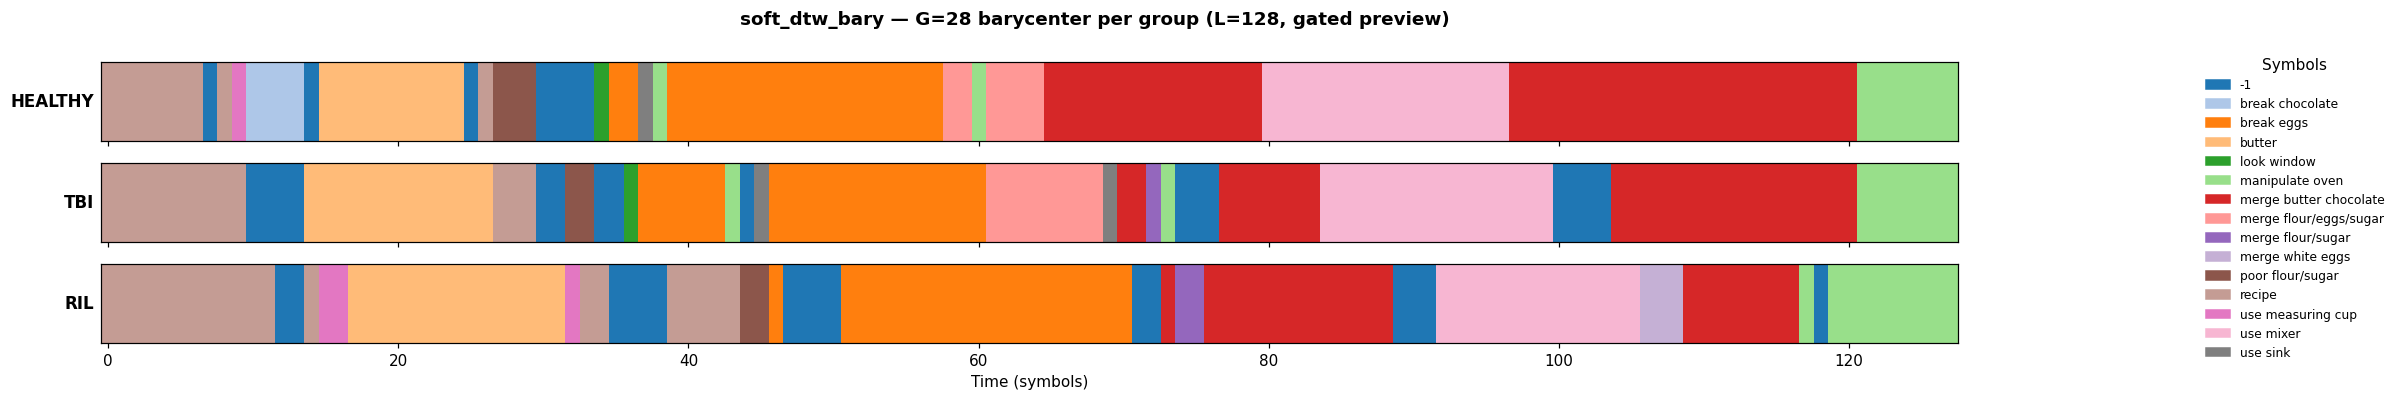

/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/barycenters/dba.py:735: ConvergenceWarning: DBA loss is increasing while it should not be. Stopping optimization.
  warnings.warn("DBA loss is increasing while it should not be. "


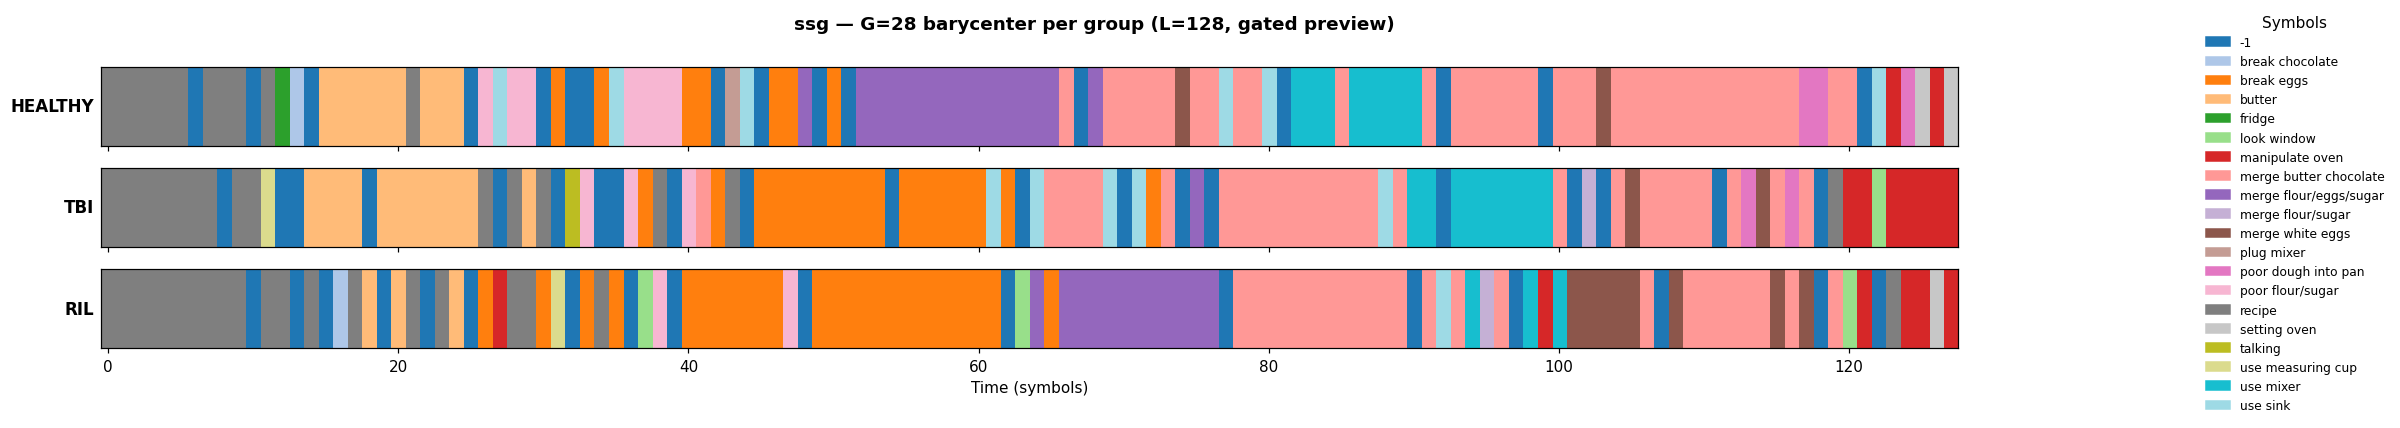

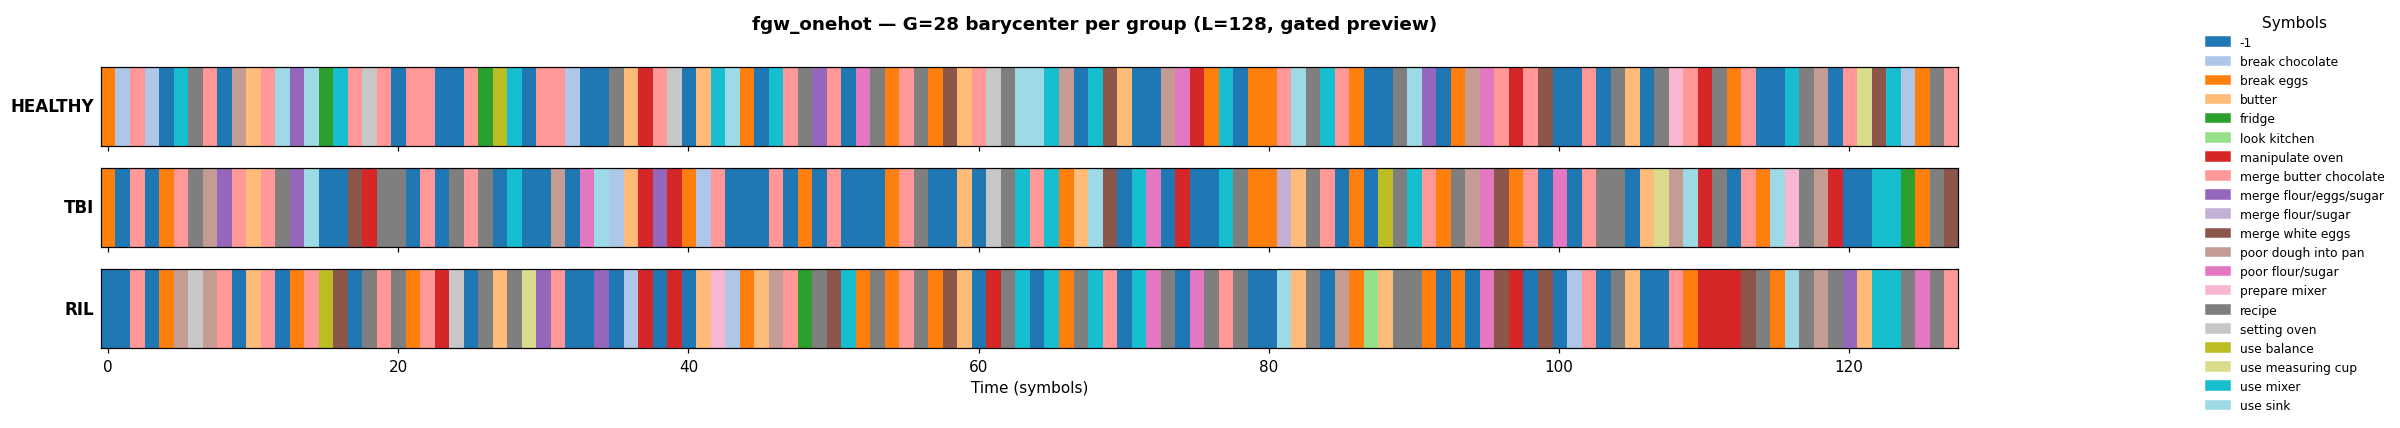

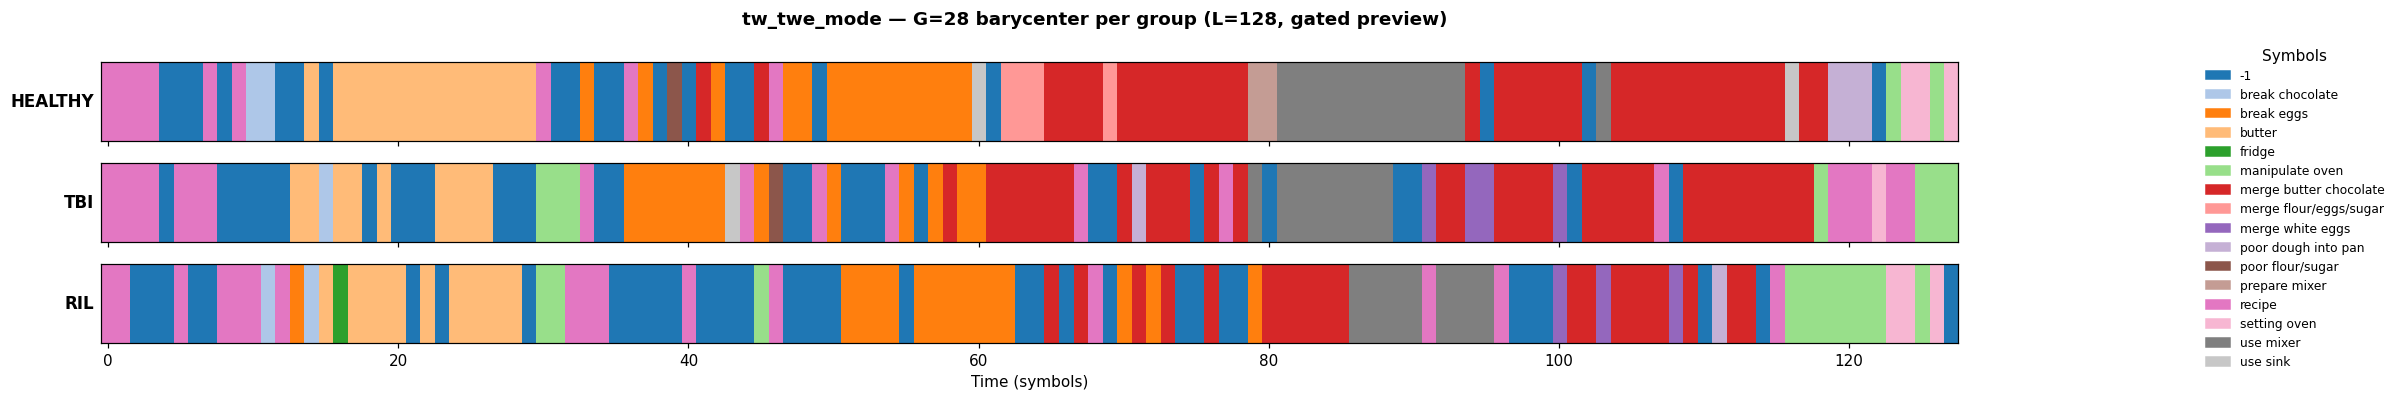

In [6]:
CHRONO_METHODS = ['soft_dtw_bary', 'ssg', 'fgw_onehot', 'tw_twe_mode']
groups = ['HEALTHY', 'TBI', 'RIL']
def _as_seq(name, spec, Xg):
    if spec.get('kind') == 'medoid':
        idx = int(np.argmin(rtwe_pairwise_distance(
            Xg.astype(np.float64), nu=NU, lmbda=LMBDA,
            precomputed_distances=np.ascontiguousarray(D_G)).sum(1)))
        return np.asarray(Xg[idx]).astype(int)
    b = np.asarray(spec['build'](Xg, RS))
    if b.ndim == 2:            # transition matrix -> skip (no sequence)
        return None
    if b.ndim == 1 and b.shape[0] == G and np.issubdtype(b.dtype, np.floating):
        return np.full(L, int(np.argmax(b)), dtype=int)   # histogram -> argmax reference strip
    return b.astype(int)

for name in CHRONO_METHODS:
    spec = methods[name]
    barys = {g: _as_seq(name, spec, X[labels == g].astype(int)) for g in groups}
    barys = {g: v for g, v in barys.items() if v is not None}
    fig = viz.plot_cohort_barycenters(barys, groups=list(barys), code_to_label=code_to_label,
                                      title=f'{name} — G=28 barycenter per group (L={L}, gated preview)')
    fig.savefig(os.path.join(EXP, f'chronogram_{name}.png'), dpi=150, bbox_inches='tight')
    display(fig); plt.close(fig)

## (5) Scale hand-off — run at full length / full cohort on `pomme`

The cell below is a **stub — NOT run locally**. It documents the full-length (L≈5162) / full-cohort
invocation for the `pomme` server, where the O(L²·G) cost is tractable on the target hardware.

In [7]:
# --- run at scale on pomme (NOT run locally) ---
# Full-length (no upsample -> ragged native L up to ~5162) + full G=28 cohort, full budget.
# O(L^2 * G) per iteration; ~1600x the per-cell cost of this L=128 preview -> pomme only.
#
# from smartflat.features.symbolic_barycenter import vocab
# from smartflat.features.symbolic_barycenter.baselines import softdtw_ssg_methods
# from smartflat.features.symbolic_barycenter.barycenter_quality import (
#     score_barycenter_quality, quality_table)
#
# L_FULL = 5162                       # or per-group native max length
# df, X, labels = vocab.load_g28_cohort(upsample_to=L_FULL)   # rectangular for lock-step scoring
# D_G = vocab.build_g28_ground_cost()
# methods = softdtw_ssg_methods(D_G, nu=1e-4, lmbda=0.1,
#                               sdtw_max_iter=50, ssg_max_iter=30)   # full budget
# res = score_barycenter_quality(X, labels, methods, D_G, n_inits=3, random_state=42)
# quality_table(res).to_csv('barycenter_quality_softdtw_ssg_FULL.csv')
print('pomme scale-run stub — not executed locally')

pomme scale-run stub — not executed locally


## Summary (→ `RESULTS_HANDOFF_barycenters.md` §18)

Two library-backed DTW-family averagers (`soft_dtw_bary`, `ssg`) now score through the same §17 harness.
Consistent with the §17 verdict, they are **rTWE-compact but less frequency-faithful** than the histogram /
`fgw_*` — an honest per-axis tradeoff, not a new winner. Numbers above are a **gated L=128 preview** with a
reduced budget; the full-length / full-cohort run is deferred to `pomme`.